In [1]:
%matplotlib inline
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_utils import (
    apply_plot_style, save_fig, ensure_dirs, load_query_clicks, load_sku_desc,
    text_len, parquet_num_rows, parquet_schema_names, dataset_overview_stats,
    save_stats, QUERY_CLICKS_PATH, SKU_DESC_PATH, SKUS_PKL_PATH,
    MVIDEO_RED, DARK_SLATE, MUTED,
)
ensure_dirs()
apply_plot_style()
pd.set_option("display.max_colwidth", 80)
print("ROOT:", ROOT)
df = load_query_clicks(n=400_000, seed=42)
desc = load_sku_desc(n=250_000, seed=42)
print("clicks", df.shape, "desc", desc.shape)


ROOT: D:\Projects-26-06-2026\mvideo-ner-search
clicks (400000, 8) desc (250000, 3)


## Топ брендов


Уникальных брендов в семпле: 3790


,clicks
sku_brand_name,
Apple,18451
Samsung,16815
Haier,9663
Xiaomi,9413
HUAWEI,9130
Tefal,6905
Gorenje,5900
Яндекс,5444
Indesit,4788


Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\03_top_brands.png


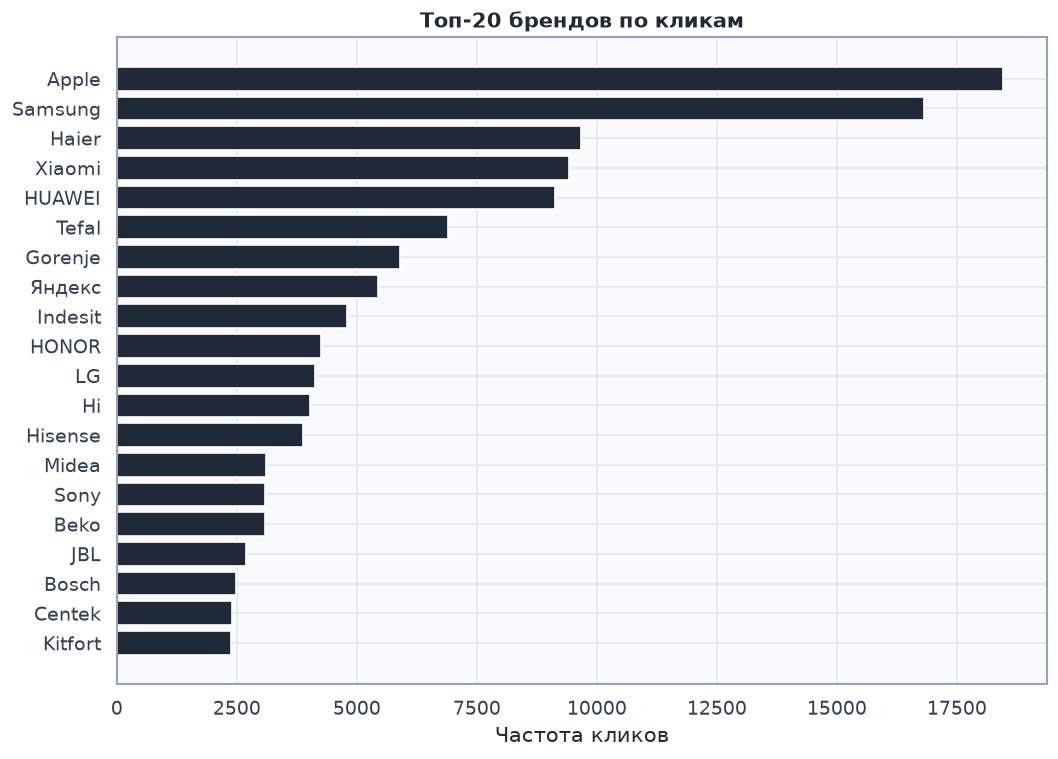

In [2]:
brands = df["sku_brand_name"].replace("", np.nan).dropna()
print("Уникальных брендов в семпле:", brands.nunique())
top_b = brands.value_counts().head(20)
display(top_b.to_frame("clicks"))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_b.index.astype(str)[::-1], top_b.values[::-1], color=DARK_SLATE)
ax.set_title("Топ-20 брендов по кликам"); ax.set_xlabel("Частота кликов")
save_fig(fig, "03_top_brands.png"); plt.show()


## Распределение цен


count    390432.000000
mean      25910.464611
std       28696.879558
min           1.000000
25%        4798.000000
50%       15616.000000
75%       35999.000000
max      144336.000000
Name: sku_price, dtype: float64
Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\04_price_distribution.png


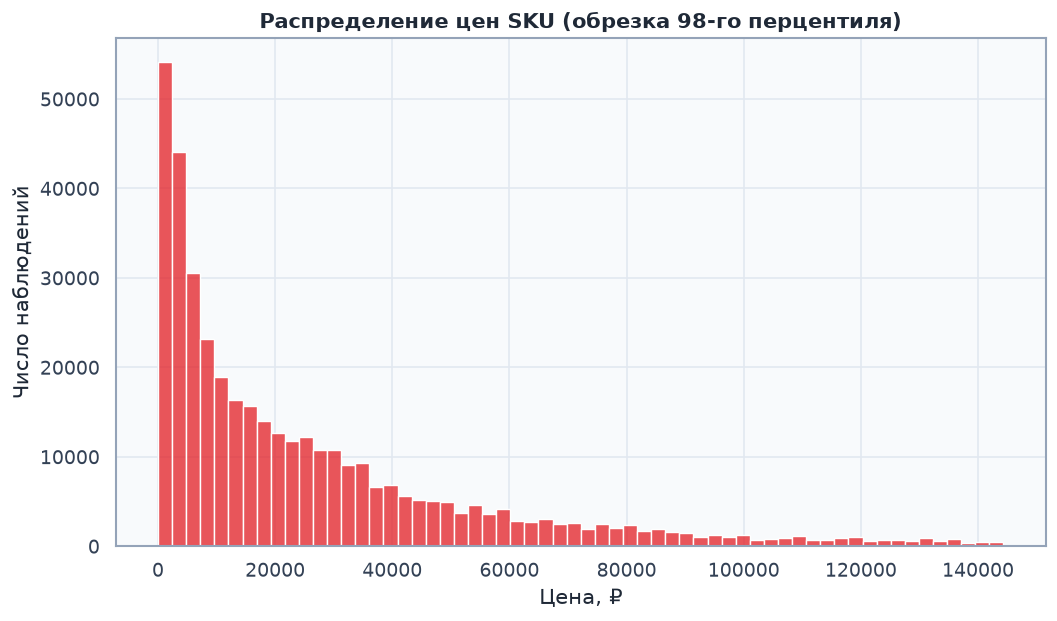

In [3]:
prices = df["sku_price"].dropna()
prices = prices[(prices > 0) & (prices < prices.quantile(0.98))]
print(prices.describe())
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(prices, bins=60, color=MVIDEO_RED, edgecolor="white", ax=ax)
ax.set_title("Распределение цен SKU (обрезка 98-го перцентиля)")
ax.set_xlabel("Цена, ₽"); ax.set_ylabel("Число наблюдений")
save_fig(fig, "04_price_distribution.png"); plt.show()


## Boxplot цен по брендам


Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\12_brand_price_boxplot.png


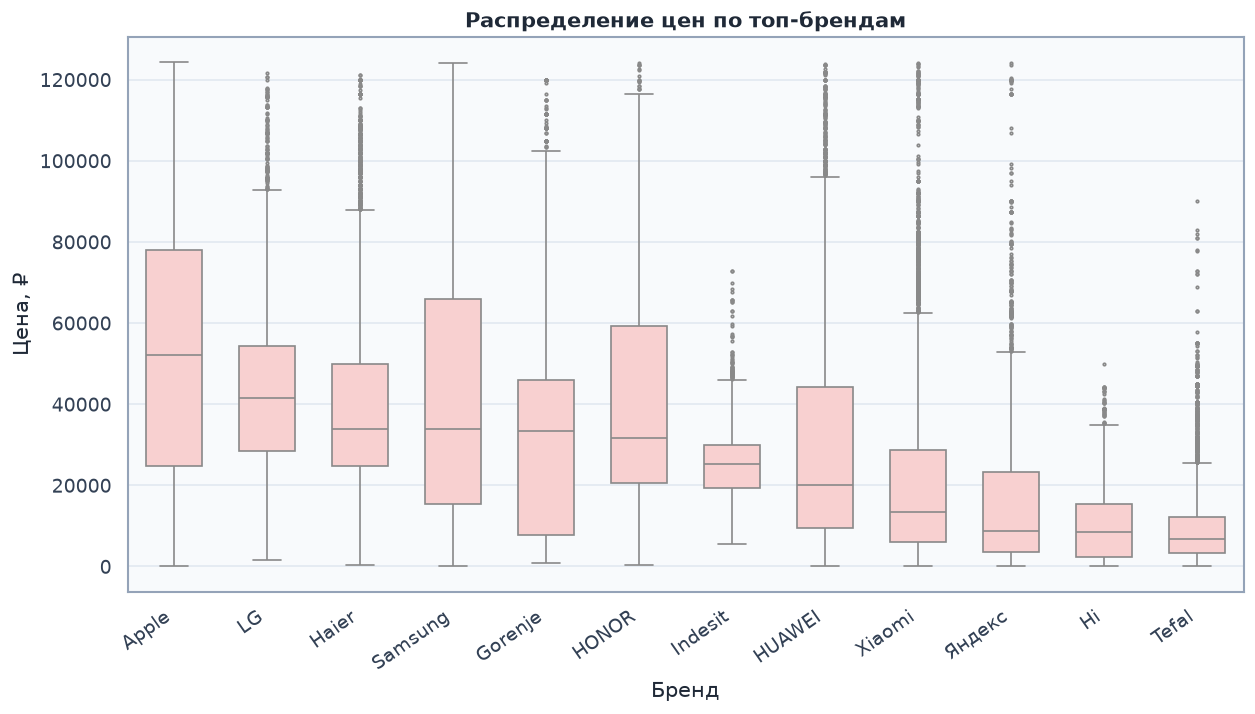

In [4]:
top12 = brands.value_counts().head(12).index
sub = df[df["sku_brand_name"].isin(top12)].copy()
sub = sub[(sub["sku_price"] > 0) & (sub["sku_price"] < sub["sku_price"].quantile(0.95))]
order = sub.groupby("sku_brand_name")["sku_price"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=sub, x="sku_brand_name", y="sku_price", order=order, color="#FECACA", width=0.6, fliersize=1.5, ax=ax)
ax.set_title("Распределение цен по топ-брендам")
ax.set_xlabel("Бренд"); ax.set_ylabel("Цена, ₽")
plt.xticks(rotation=35, ha="right")
save_fig(fig, "12_brand_price_boxplot.png"); plt.show()


## Категории (sku_subject_id)


Уникальных subject в семпле: 2158


Сохранено: C:\Users\kamau\Documents\мвидео\figures\08_subject_distribution.png


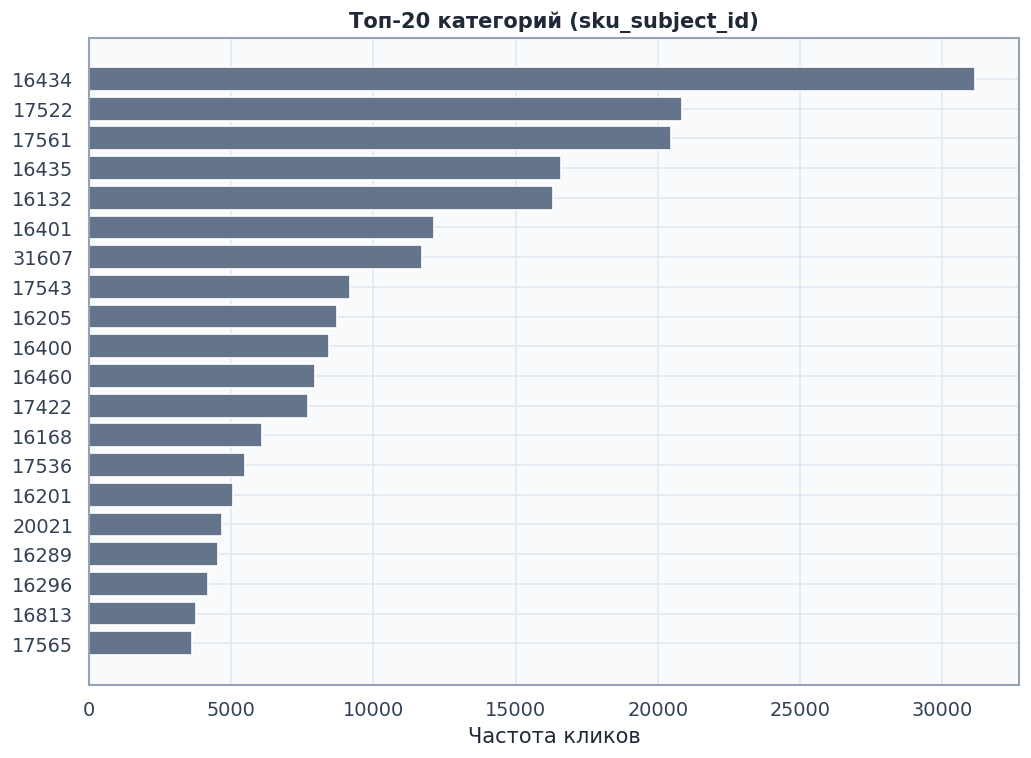

In [5]:
print("Уникальных subject в семпле:", df["sku_subject_id"].nunique())
subj = df["sku_subject_id"].astype(str).value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(subj.index.astype(str)[::-1], subj.values[::-1], color=MUTED)
ax.set_title("Топ-20 категорий (sku_subject_id)"); ax.set_xlabel("Частота кликов")
save_fig(fig, "08_subject_distribution.png"); plt.show()


## Длины title / description


title: count    250000.000000
mean         45.895632
std          23.871826
min           7.000000
25%          29.000000
50%          43.000000
75%          58.000000
max         280.000000
Name: title, dtype: float64
description: count    250000.000000
mean        752.499212
std         610.985979
min           4.000000
25%         306.000000
50%         630.000000
75%        1047.000000
max       27525.000000
Name: description, dtype: float64


Сохранено: C:\Users\kamau\Documents\мвидео\figures\09_title_length_dist.png


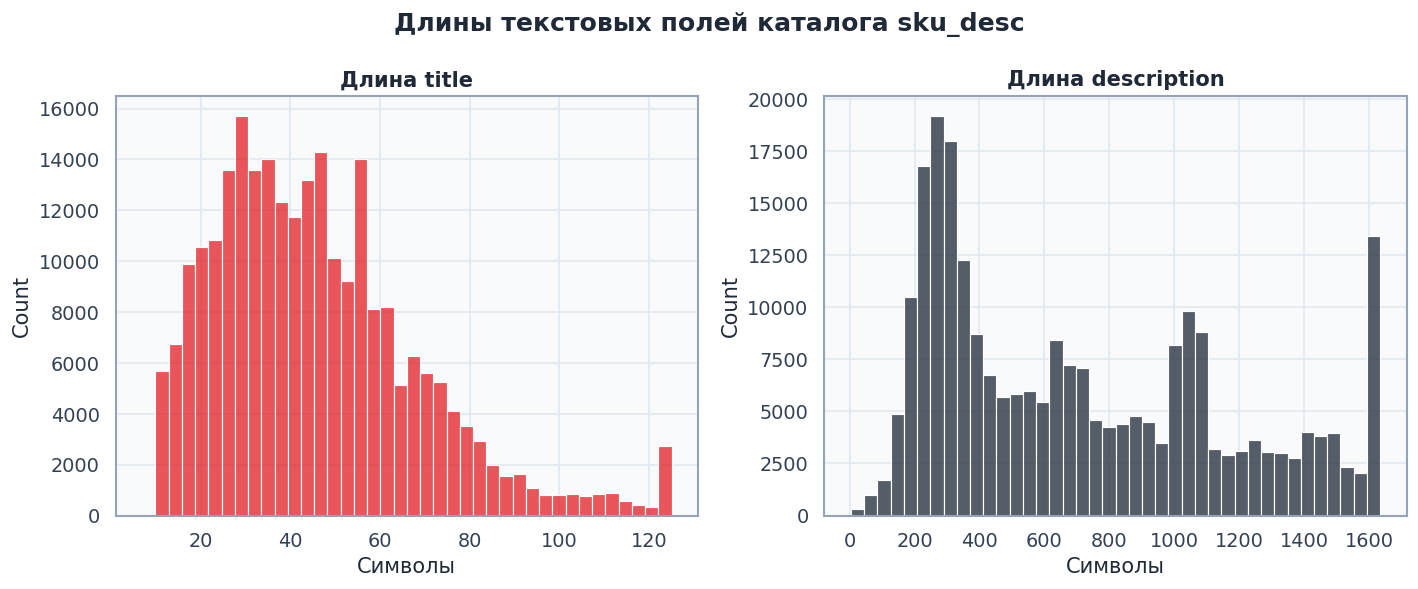

In [6]:
tlen = text_len(desc["title"]); dlen = text_len(desc["description"])
print("title:", tlen.describe()); print("description:", dlen.describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(tlen.clip(upper=tlen.quantile(0.99)), bins=40, color=MVIDEO_RED, ax=axes[0], edgecolor="white")
axes[0].set_title("Длина title"); axes[0].set_xlabel("Символы")
sns.histplot(dlen.clip(upper=dlen.quantile(0.95)), bins=40, color=DARK_SLATE, ax=axes[1], edgecolor="white")
axes[1].set_title("Длина description"); axes[1].set_xlabel("Символы")
fig.suptitle("Длины текстовых полей каталога sku_desc", fontweight="bold"); fig.tight_layout()
save_fig(fig, "09_title_length_dist.png"); plt.show()
